# Práctica 5 sobre gráficas de funciones de dos variables

## Curvas de nivel
Podemos representar la gráfica de una función usando variables simbólicas con `plot3d`:

In [2]:
f = lambda x,y: x^2+y^2
var('x y')
plot3d(f, (x,-1,1), (y,-1,1))

Graphics3d Object

Pero es más manejable representar las curvas de nivel.

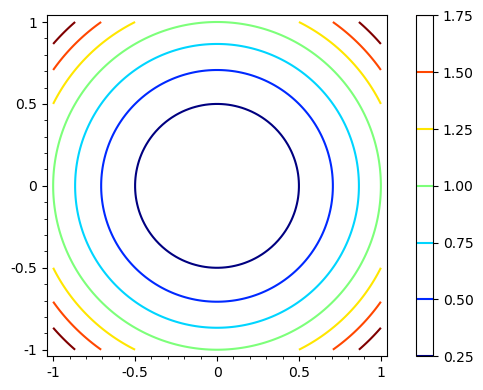

In [14]:
contour_plot(f, (x,-1,1), (y,-1,1), fill=False, cmap='jet', colorbar=True)

Los argumentos opcionales de `countour_plot` más relevantes son:

- `fill`, sobre si colorear o no el espacio entre las curvas de nivel: `True`/`False`.
- `cmap`, para definir,
  - el esquema de colores si se da un color _colormap_: `'jet'`, `'rainbow'`, `'coolwarm'`, `'terrain'`, etc.
  - un color a usar si se da una lista: `['blue']`, `['green']`, `['red']`, etc.
- `colorbar`, para añadir o no una barra lateral con la escala de valores: `True`/`False`.
- `contours` para definir,
  - cuántas curvas de nivel se dibujan, si se da un entero: `20`;
  - los valores de las curvas de nivel, si se da una lista: `[-1 0 1]`.
- `labels`, para indicar o no el valor de cada curva: `True`/`False`.
- `linestyles`, para indicar el estilo de línea: `'solid'`, `'dashed'`, `'dashdot'`, `'dotted'`.

Para reutilizar varios de estos argumentos, es habitual agruparlos en un diccionario Python y usarlo, como último argumento de `contour_plot`, con el operador de desempaquetamiento de diccionarios `**`.

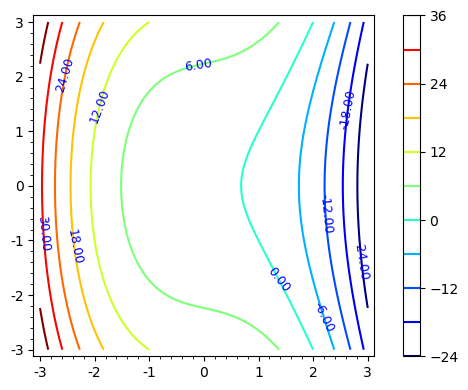

In [16]:
g = lambda x,y: y^2+1-x^3-x
opts = {'fill':False, 'cmap':'jet', 'contours':12, 'labels':True, 'colorbar':True}
contour_plot(g, (x,-3,3), (y,-3,3), **opts)

## Visualización de raíces de funciones de dos variables
Las soluciones de un sistema de dos ecuaciones y dos incógnitas como

$\left\{\begin{array}{l} x^2+2y = y^2\\ 2x+y^2=6 \end{array}\right.$

son equivalentes a las raíces de la función

$\displaystyle \mathbf{f}(x,y) = \left(\begin{array}{c} f_1(x,y)\\ f_2(x,y) \end{array}\right) = \left(\begin{array}{c} x^2-y^2+2y\\ 2x+y^2-6 \end{array}\right).$

A su vez, las raíces de $\mathbf{f} $ deben estar en las curvas de nivel cero de $f_1$ y $f_2$ a la vez, es decir, son los puntos de intersección de ambas curvas de nivel.

Empezamos por definir la función de dos variables con salida una lista de dos componentes.

In [63]:
f = lambda x,y: [x^2-y^2+2*y, 2*x+y^2-6]

Las componentes $f_1$ y $f_2$ son los elementos de la lista, `f[0]` y `f[1]`, respectivamente. Ahora pintamos sus curvas de nivel cero, la primera en azul y la segunda en verde,

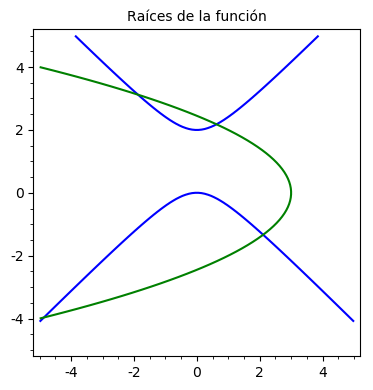

In [42]:
var('x y')
opts = {'fill':False, 'contours':[0]}
g1 = contour_plot(f(x,y)[0], (x,-5,5), (y,-5,5), cmap=['blue'],  **opts)
g2 = contour_plot(f(x,y)[1], (x,-5,5), (y,-5,5), cmap=['green'], **opts)
show(g1+g2, title='Raíces de la función')

Observa que `contours=[0]` ordena pintar la curva de nivel cero; `contours=0` sería incorrecto porque ordenaría pintar cero curvas de nivel.

**Ejercicio 1:** 
1. Identifica las raíces de la función 
$\displaystyle \mathbf{f}(x,y) = \left(\begin{array}{c} 3x^2-y^2\\ 3xy^2-x^3-1 \end{array}\right)$ en $[-5,5]\times[-5,5]$ pintando las curvas de nivel cero de sus componentes.
2. Ídem para $\displaystyle \mathbf{f}(x,y) = \left(\begin{array}{c} \log(x^2+y^2)-\sin(xy)-\log(2)-\log(\pi)\\ \exp(x-y)+\cos(xy); \end{array}\right).$

Por comodidad, usa la siguiente función auxiliar.

In [64]:
def raices(f, x0=-5, x1=5, y0=-5, y1=5):
    var('x y')
    opts = {'fill':False, 'contours':[0]}
    g1 = contour_plot(f(x,y)[0], (x, x0, x1), (y, y0, y1), cmap=['blue'],  **opts)
    g2 = contour_plot(f(x,y)[1], (x, x0, x1), (y, y0, y1), cmap=['green'], **opts)
    return g1+g2

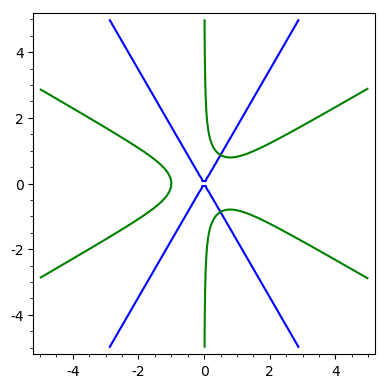

In [65]:
raices(lambda x,y: [3*x^2-y^2, 3*x*y^2-x^3-1])

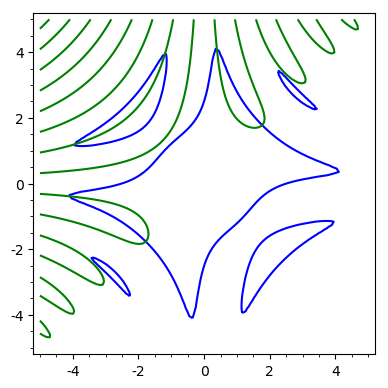

In [50]:
f = lambda x,y: [log(x^2+y^2)-sin(x*y)-log(2)-log(pi), exp(x-y)+cos(x*y)]
raices(f)

Veamos más de cerca si hay una raíz aproximadamente en $(3,3)$. Comprobamos que no es así.

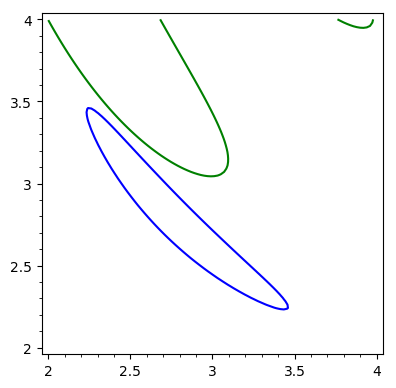

In [51]:
raices(f, 2, 4, 2, 4)

## Extremos de funciones

Cando buscamos los extremos de una función de dos variables, es útil entender cómo son las curvas de nivel alrededor de sus máximos, mínimos y puntos de silla.

Por ejemplo, la función $z = x^2+y^2$ tiene un mínimo en $(0,0)$, como puede verse con `plot3d`.

In [54]:
z = lambda x,y: x^2+y^2
var('x y')
plot3d(z, (x,-1,1), (y,-1,1))

Graphics3d Object

Se observa que las curvas de nivel **se cierran** en torno a ese punto y **suben** de valor al alejarse de él.

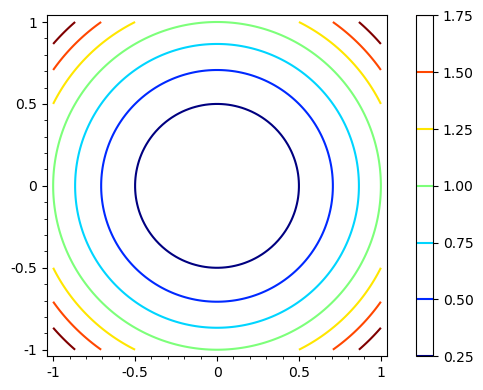

In [61]:
opts = {'fill':False, 'cmap':'jet', 'colorbar':True}
contour_plot(f, (x,-1,1), (y,-1,1), **opts)

La función $z = -x^2-y^2$ tiene un maximo en $(0,0)$.

In [58]:
z = lambda x,y: -x^2-y^2
plot3d(z, (x,-1,1), (y,-1,1))

Graphics3d Object

Se observa que las curvas de nivel **se cierran** en torno a ese punto y **bajan** de valor al alejarse de él.

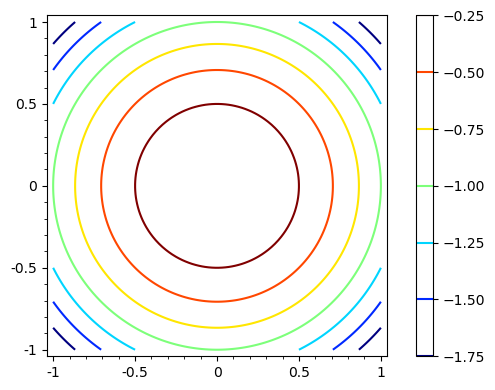

In [29]:
contour_plot(f, (x,-1,1), (y,-1,1), **opts)

La función $z = x^2-y^2$ tiene un punto de silla en $(0,0)$.

In [30]:
f = lambda x,y: x^2-y^2
plot3d(f, (x,-1,1), (y,-1,1))

Graphics3d Object

Se observa que las curvas de nivel **no se cierran**, pero se comporta como un **mínimo en una dirección** (en este caso, en la del eje OX) y como un **máximo en otra** (eje OY).

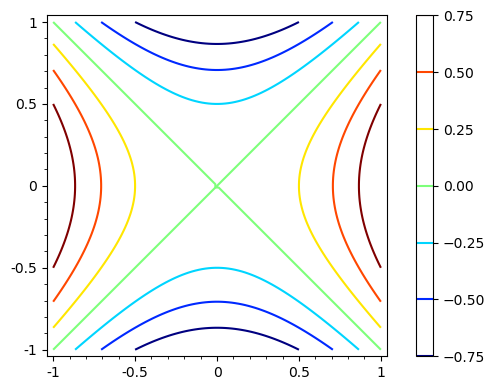

In [31]:
contour_plot(f, (x,-1,1), (y,-1,1), **opts)

Ahora consideremos una función en la que los tres tipos aparecen.

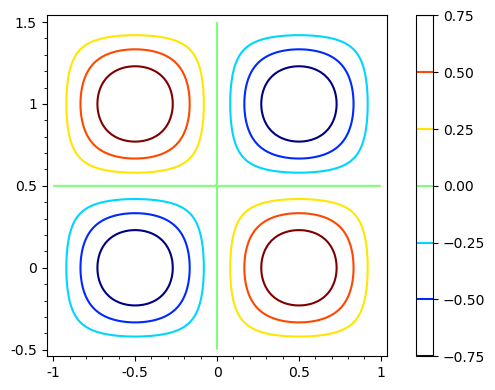

In [59]:
h = lambda x,y: sin(pi*x)*cos(pi*y)
contour_plot(h, (x,-1,1), (y,-0.5,1.5), **opts)

Se pueden observar mínimos en $(-\frac{1}{2},0)$ y $(\frac{1}{2},1)$, máximos en $(-\frac{1}{2},1)$ y $(\frac{1}{2},0)$ y un punto de silla en $(0,\frac{1}{2})$. 

**Exercicio 2:**
1. Identifica si la función $h(x,y) = -x^4+y^3-32x-12y+5$ tiene máximos, mínimos o puntos de silla en $[-5,5]\times [-5,5]$.

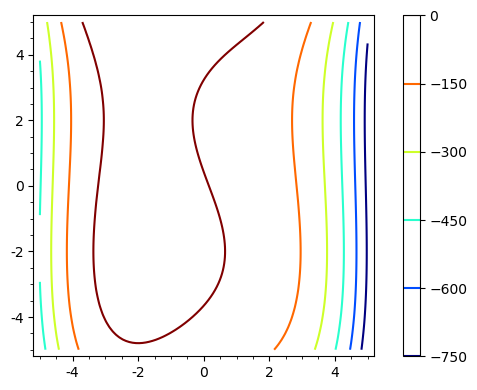

In [60]:
h(x,y) = -x^4+y^3-32*x-12*y+5
contour_plot(h, (x, -5, 5), (y, -5, 5), **opts)

Aumentamos o número de curvas de nivel. 

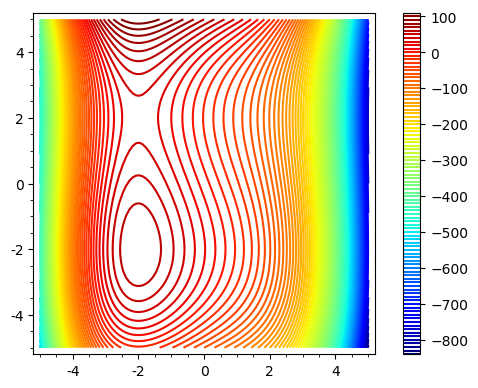

In [62]:
contour_plot(h, (x, -5, 5), (y, -5, 5), contours=100, **opts)

Ahora apreciamos un máximo en $(-2,-2)$ y un punto de silla en $(-2,2)$.